In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import os

os.listdir()

['chronic_disease.ipynb', 'chronic_disease_project.csv']

In [10]:
import pandas as pd

df = pd.read_csv("chronic_disease_project.csv")

df.head()

,PatientID,Date,Age,Gender,Disease,MedicalHistory,Lifestyle,BiomarkerScore,MedicationDose,HeartRate
0,PID0024,2022-08-31,53,Male,Alzheimer's,Heart Disease,Non-Smoker,22.81,1.85,71
1,PID0248,2023-10-28,44,Male,Diabetes,Heart Disease,Active,6.67,0.67,82
2,PID0031,2023-03-17,87,Female,Parkinson's,Asthma,Occasional Drinker,46.73,1.60,70
3,PID0319,2023-07-17,76,Female,Parkinson's,Stroke,Sedentary,51.21,1.84,73
4,PID0308,2022-05-14,59,Female,Diabetes,Stroke,Sedentary,6.62,1.71,64


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PatientID       3000 non-null   object 
 1   Date            3000 non-null   object 
 2   Age             3000 non-null   int64  
 3   Gender          3000 non-null   object 
 4   Disease         3000 non-null   object 
 5   MedicalHistory  2352 non-null   object 
 6   Lifestyle       3000 non-null   object 
 7   BiomarkerScore  3000 non-null   float64
 8   MedicationDose  3000 non-null   float64
 9   HeartRate       3000 non-null   int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 234.5+ KB


In [12]:
df.shape

(3000, 10)

In [13]:
df.describe()

,Age,BiomarkerScore,MedicationDose,HeartRate
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,63.790667,20.764657,1.257277,79.506333
std,14.759047,13.147806,0.430105,11.605265
min,40.000000,-1.910000,0.500000,60.000000
25%,51.000000,7.910000,0.900000,69.000000
50%,63.000000,19.625000,1.270000,79.000000
75%,77.000000,29.447500,1.630000,90.000000
max,89.000000,65.970000,2.000000,99.000000


In [14]:
df.isnull().sum()

PatientID           0
Date                0
Age                 0
Gender              0
Disease             0
MedicalHistory    648
Lifestyle           0
BiomarkerScore      0
MedicationDose      0
HeartRate           0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["MedicalHistory"].value_counts()

MedicalHistory
Heart Disease    675
Hypertension     583
Asthma           557
Stroke           537
Name: count, dtype: int64

In [17]:
df.isnull().sum()

PatientID           0
Date                0
Age                 0
Gender              0
Disease             0
MedicalHistory    648
Lifestyle           0
BiomarkerScore      0
MedicationDose      0
HeartRate           0
dtype: int64

In [18]:
df["MedicalHistory"] = df["MedicalHistory"].fillna(
    df["MedicalHistory"].mode()[0]
)

In [20]:
df.isnull().sum()

PatientID         0
Date              0
Age               0
Gender            0
Disease           0
MedicalHistory    0
Lifestyle         0
BiomarkerScore    0
MedicationDose    0
HeartRate         0
dtype: int64

In [21]:
df.columns

Index(['PatientID', 'Date', 'Age', 'Gender', 'Disease', 'MedicalHistory',
       'Lifestyle', 'BiomarkerScore', 'MedicationDose', 'HeartRate'],
      dtype='object')

In [22]:
df.shape

(3000, 10)

In [23]:
def stage(score):
    if score < 15:
        return "Early"
    elif score < 30:
        return "Mid"
    else:
        return "Late"

df["DiseaseStage"] = df["BiomarkerScore"].apply(stage)

In [24]:
df["DiseaseStage"].value_counts()

DiseaseStage
Early    1169
Mid      1115
Late      716
Name: count, dtype: int64

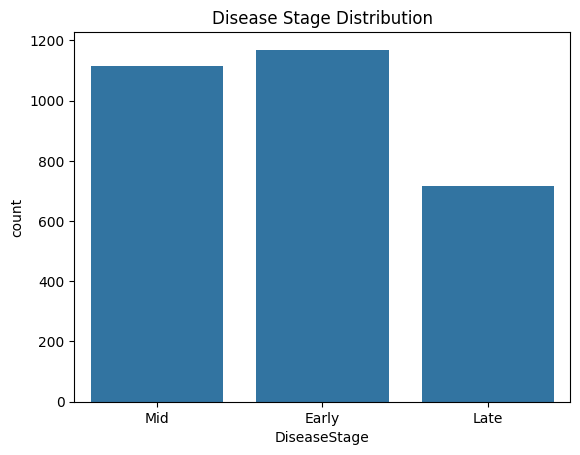

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="DiseaseStage", data=df)
plt.title("Disease Stage Distribution")
plt.show()

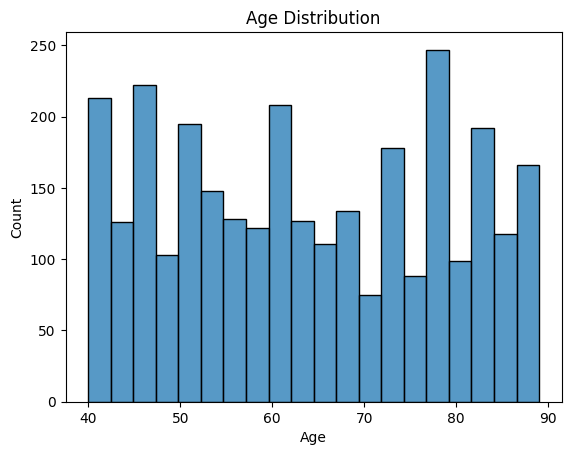

In [26]:
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ["Gender","Disease","MedicalHistory","Lifestyle","DiseaseStage"]:
    df[col] = le.fit_transform(df[col])

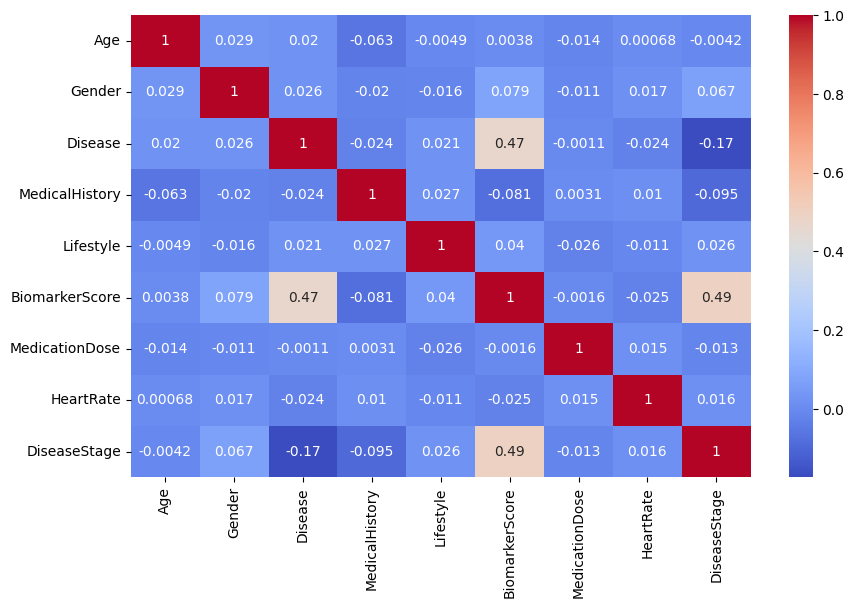

In [28]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [29]:
X = df.drop(
    ["PatientID","Date","DiseaseStage"],
    axis=1
)

y = df["DiseaseStage"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
df["DiseaseStage"].value_counts()

DiseaseStage
0    1169
2    1115
1     716
Name: count, dtype: int64

In [32]:
X.dtypes

Age                 int64
Gender              int64
Disease             int64
MedicalHistory      int64
Lifestyle           int64
BiomarkerScore    float64
MedicationDose    float64
HeartRate           int64
dtype: object

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [34]:
y_pred = rf_model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9983333333333333


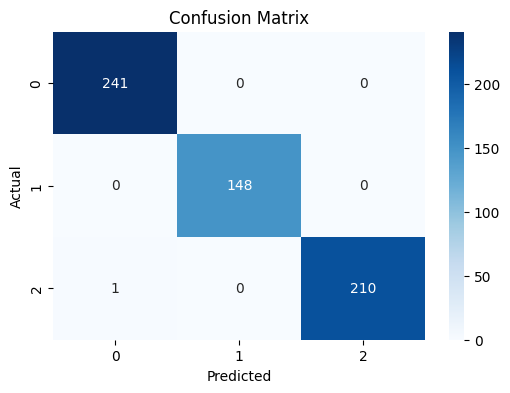

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       241
           1       1.00      1.00      1.00       148
           2       1.00      1.00      1.00       211

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



In [38]:
import pandas as pd

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

          Feature  Importance
5  BiomarkerScore    0.700039
2         Disease    0.237101
0             Age    0.017887
6  MedicationDose    0.016818
7       HeartRate    0.013887
4       Lifestyle    0.006517
3  MedicalHistory    0.005707
1          Gender    0.002044


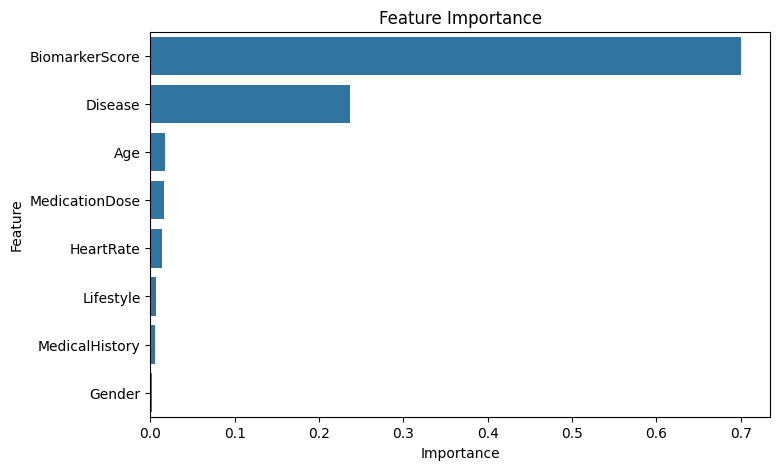

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()